# EMA 6938 — Data Science for Materials
## Week 6 Notebook: Regression and Predictive Modeling

**Name:** *Ryan Tuggle*  
**Date:** *6/20/2026*  
**Kernel:** Python (matds)

---

**Chapters:** Sandfeld Ch. 12–13  
**Format:** Take-home — due **Sunday 11:59 PM**  
**Dataset:** `data/week6_mp_formation_energy.csv` (instructor-provided, save in the same folder as this notebook)

---

### How to use this notebook
- **Demo cells** (`# LECTURE DEMO`) reproduce examples from the lecture. Run them, understand them.
- **Task cells** (`# YOUR CODE HERE`) require you to write code.
- **Reflection cells** require written markdown answers. Replace the italic placeholder text.

This notebook has six parts:

| Part | Title | Connects to |
|------|-------|-------------|
| A | Load & Inspect | Lecture Segment 1–2 |
| B | Split & Scale | Lecture Segment 2 |
| C | OLS, Ridge & Lasso | Lecture Segments 2–4 |
| D | Polynomial Extension | Lecture Segment 5 |
| E | RF Baseline | Lecture Segment 5 |
| F | Reflection | All segments |

---

**Submission:** Upload this `.ipynb` file to Canvas. Run `Kernel → Restart & Run All` before submitting to confirm all cells execute cleanly.

> **AI tool disclosure:** If you used any AI coding assistant (GitHub Copilot, ChatGPT, etc.) while completing this notebook, describe briefly which tool, for what purpose, and what you verified yourself. Delete this line if no AI tools were used.
---

**Model Critique Essay reminder:** Due this week! Submit via Canvas.


In [3]:
# Cell 0 - Environment check
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, Lasso, LassoCV
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split, validation_curve, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print(f"Python:    {sys.version.split()[0]}")
print(f"NumPy:     {np.__version__}")
print(f"pandas:    {pd.__version__}")
import sklearn; print(f"sklearn:   {sklearn.__version__}")
print("\n✅ Environment OK")

Python:    3.11.15
NumPy:     2.4.6
pandas:    2.3.3
sklearn:   1.9.0

✅ Environment OK


---
## Part A - Load & Inspect
**Connects to: Lecture Segments 1–2, Sandfeld Ch. 12**

### A1 - Load the dataset
**Lecture demo - reproduce and understand**

In [4]:
# Cell A1 — Load the formation energy dataset
# LECTURE DEMO

df = pd.read_csv('data/week6_mp_formation_energy.csv')

print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nTarget — Ef_eV_atom:")
print(df['Ef_eV_atom'].describe().round(4))

Shape: 87,744 rows × 138 columns

Target — Ef_eV_atom:
count    87744.0000
mean        -1.5485
std          1.0591
min         -4.5243
25%         -2.4391
50%         -1.5190
75%         -0.5581
max          0.0997
Name: Ef_eV_atom, dtype: float64


### A2 - Inspect the formation energy distribution
**Lecture demo**

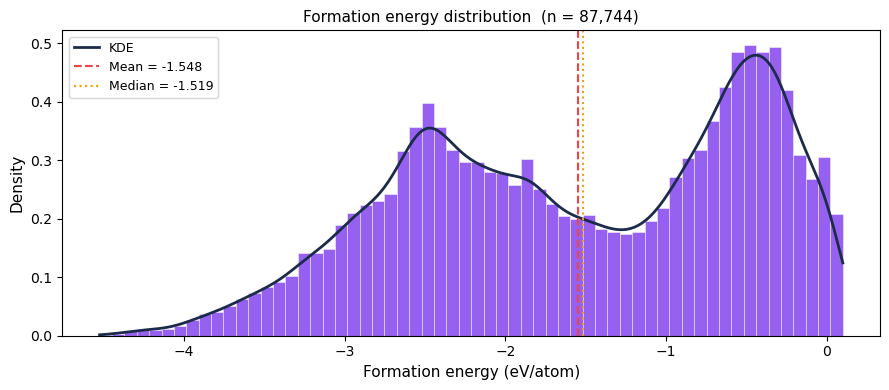

In [5]:
# Cell A2 — Histogram + KDE of formation energy
# LECTURE DEMO

from scipy.stats import gaussian_kde

ef = df['Ef_eV_atom'].dropna()
fig, ax = plt.subplots(figsize=(9, 4))

ax.hist(ef, bins=60, color='#7C3AED', alpha=0.80,
        density=True, edgecolor='white', linewidth=0.4)
x_kde = np.linspace(ef.min(), ef.max(), 400)
ax.plot(x_kde, gaussian_kde(ef)(x_kde), color='#1C2B4A', lw=2, label='KDE')
ax.axvline(ef.mean(),   color='#EF4444', lw=1.5, ls='--',
           label=f'Mean = {ef.mean():.3f}')
ax.axvline(ef.median(), color='#F59E0B', lw=1.5, ls=':',
           label=f'Median = {ef.median():.3f}')

ax.set_xlabel('Formation energy (eV/atom)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title(f'Formation energy distribution  (n = {len(ef):,})', fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('A2_ef_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

**A2 Reflection** *(answer in this cell)*

Compare the shape of the formation energy distribution to the band gap distribution
from Week 4. Is formation energy more or less Gaussian? Provide a physical reason. Why would the Central Limit Theorem apply more strongly to formation energy than to band gap?

*Your answer here:*

The formation energy is more Gaussian than the bandgap. The physical reason for this is that bandgap is not the result of many small independent random effects like formation energy and is also strongly bimodal with a distribution showing a large spike at 0 eV for metals. The central limit theorem applies more stongly to formation energy than bandgap because formation energies are a single population created by additive effects while bandgap contains two populations that are non-additive in nature.

### A3 - Set up feature matrix and drop missing values
**Lecture demo**

In [6]:
# Cell A3 — Set up X, y and drop missing values
# LECTURE DEMO

non_feature_cols = ['mp_id', 'formula', 'band_gap', 'Ef_eV_atom',
                    'crystal_system', 'composition']
feature_cols = [c for c in df.columns
                if c not in non_feature_cols
                and df[c].dtype in ['float64', 'float32']]

n_before = len(df)
df = df.dropna(subset=['Ef_eV_atom'] + feature_cols).reset_index(drop=True)
print(f"MAGPIE features: {len(feature_cols)}")
print(f"Rows dropped:    {n_before - len(df)}")
print(f"Rows remaining:  {len(df):,}")

X = df[feature_cols].values
y = df['Ef_eV_atom'].values
print(f"\nX shape: {X.shape}    y range: [{y.min():.3f}, {y.max():.3f}] eV/atom")

MAGPIE features: 132
Rows dropped:    0
Rows remaining:  87,744

X shape: (87744, 132)    y range: [-4.524, 0.100] eV/atom


---
## Part B - Split & Scale
**Connects to: Lecture Segment 2, Sandfeld Ch. 12**

### B1 - Stratified train/test split
**Lecture demo — reproduce and understand**

In [7]:
# Cell B1 — Stratified 80/20 split on Ef_eV_atom
# LECTURE DEMO

y_binned = pd.cut(y, bins=10, labels=False)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y_binned
)

print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")
print(f"y_train — mean: {y_train.mean():.4f}  std: {y_train.std():.4f} eV/atom")
print(f"y_test  — mean: {y_test.mean():.4f}  std: {y_test.std():.4f} eV/atom")

Train: 70,195  |  Test: 17,549
y_train — mean: -1.5483  std: 1.0594 eV/atom
y_test  — mean: -1.5491  std: 1.0576 eV/atom


### B2 - Fit StandardScaler on the training set only
**Lecture demo**

In [8]:
# Cell B2 — Fit scaler on train, transform both sets
# LECTURE DEMO

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"X_train_scaled — mean: {X_train_scaled.mean():.4f}  std: {X_train_scaled.std():.4f}")
print(f"X_test_scaled  — mean: {X_test_scaled.mean():.4f}  (not guaranteed ~0)")
print("\nWarning: Scaler fit on X_train only — fitting on X_test would be data leakage.")

X_train_scaled — mean: -0.0000  std: 1.0000
X_test_scaled  — mean: 0.0007  (not guaranteed ~0)



---
## Part C - OLS, Ridge & Lasso
**Connects to: Lecture Segments 2–4, Sandfeld Ch. 12–13**

### C1 - Ordinary Least Squares
**Lecture demo — reproduce and understand**

In [9]:
# Cell C1 — OLS regression
# LECTURE DEMO

ols = LinearRegression()
ols.fit(X_train_scaled, y_train)
y_pred_ols = ols.predict(X_test_scaled)

r2_ols   = r2_score(y_test, y_pred_ols)
mae_ols  = mean_absolute_error(y_test, y_pred_ols)
rmse_ols = np.sqrt(mean_squared_error(y_test, y_pred_ols))

print("OLS:")
print(f"  R²:   {r2_ols:.3f}")
print(f"  MAE:  {mae_ols:.3f} eV/atom")
print(f"  RMSE: {rmse_ols:.3f} eV/atom")

# Top 5 positive (destabilising) and negative (stabilising) coefficients
coef_s = pd.Series(ols.coef_, index=feature_cols).sort_values()
print("\nTop 5 most negative coefficients (stabilising features):")
print(coef_s.head(5).round(4).to_string())
print("\nTop 5 most positive coefficients (destabilising features):")
print(coef_s.tail(5).round(4).to_string())

OLS:
  R²:   0.919
  MAE:  0.231 eV/atom
  RMSE: 0.300 eV/atom

Top 5 most negative coefficients (stabilising features):
MagpieData mean Number                 -3.3973
MagpieData mode AtomicWeight           -1.4633
MagpieData mean Row                    -0.9599
MagpieData avg_dev Electronegativity   -0.5602
MagpieData mean NpValence              -0.4168

Top 5 most positive coefficients (destabilising features):
MagpieData mean GSbandgap         0.2695
MagpieData mean NdValence         0.2973
MagpieData mean CovalentRadius    1.1287
MagpieData mode Number            1.8414
MagpieData mean AtomicWeight      3.4128


**C1 Reflection** *(answer in this cell)*

Identify the single most negative OLS coefficient, that is, the feature most associated
with thermodynamic stability (more negative Ef). Provide a physical explanation:
why would high values of that composition descriptor correspond to more stable compounds?

*Your answer here:*
The most stabilizing feaure is mean Number. The physical reason why high values of this number correspond to more stable compounds is that when a compound has a higher mean atomic number it correlates with consituent elements having deeper potential wells, higher polarizability, and more complex bonding regimes involving d and f orbitals. 

### C2 - Ridge regression with cross-validated alpha
**Lecture demo**

RidgeCV best alpha: 0.0072
Ridge  R²:   0.919
Ridge  MAE:  0.231 eV/atom


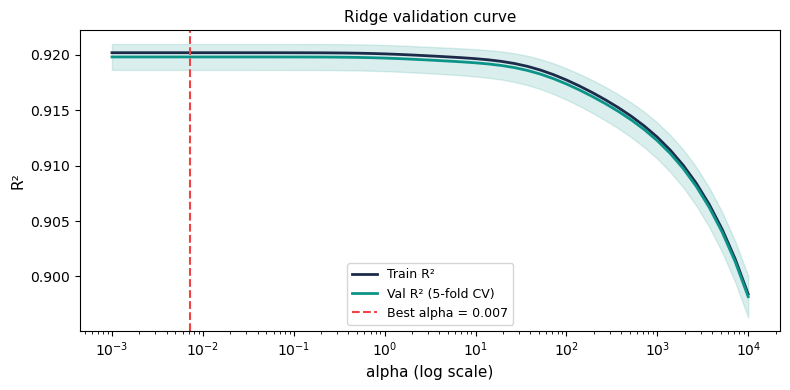

In [10]:
# Cell C2 — RidgeCV + validation curve
# LECTURE DEMO

alphas = np.logspace(-3, 4, 50)
ridge_cv = RidgeCV(alphas=alphas, cv=5, scoring='r2')
ridge_cv.fit(X_train_scaled, y_train)
y_pred_ridge = ridge_cv.predict(X_test_scaled)

r2_ridge   = r2_score(y_test, y_pred_ridge)
mae_ridge  = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

print(f"RidgeCV best alpha: {ridge_cv.alpha_:.4f}")
print(f"Ridge  R²:   {r2_ridge:.3f}")
print(f"Ridge  MAE:  {mae_ridge:.3f} eV/atom")

# Validation curve
from sklearn.linear_model import Ridge as RidgePlain
tr_scores, val_scores = validation_curve(
    RidgePlain(), X_train_scaled, y_train,
    param_name='alpha', param_range=alphas,
    cv=5, scoring='r2', n_jobs=-1
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(alphas, tr_scores.mean(1),  color='#1C2B4A', lw=2, label='Train R²')
ax.semilogx(alphas, val_scores.mean(1), color='#0D9488', lw=2, label='Val R² (5-fold CV)')
ax.fill_between(alphas, val_scores.mean(1)-val_scores.std(1),
                         val_scores.mean(1)+val_scores.std(1), alpha=0.15, color='#0D9488')
ax.axvline(ridge_cv.alpha_, color='#EF4444', lw=1.5, ls='--',
           label=f'Best alpha = {ridge_cv.alpha_:.3f}')
ax.set_xlabel('alpha (log scale)', fontsize=11)
ax.set_ylabel('R²', fontsize=11)
ax.set_title('Ridge validation curve', fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('C2_ridge_validation_curve.png', dpi=150, bbox_inches='tight')
plt.show()

### C3 - Lasso regression with coefficient path
**Lecture demo**

In [11]:
# Cell C3 — LassoCV + report surviving features
# LECTURE DEMO

alphas_l = np.logspace(-3, 1, 60)
lasso_cv = LassoCV(alphas=alphas_l, cv=5, max_iter=10000, n_jobs=-1)
lasso_cv.fit(X_train_scaled, y_train)
y_pred_lasso = lasso_cv.predict(X_test_scaled)

r2_lasso   = r2_score(y_test, y_pred_lasso)
mae_lasso  = mean_absolute_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
n_nonzero  = (lasso_cv.coef_ != 0).sum()

print(f"LassoCV best alpha: {lasso_cv.alpha_:.6f}")
print(f"Non-zero features:  {n_nonzero} / {len(feature_cols)}")
print(f"Lasso  R²:   {r2_lasso:.3f}")
print(f"Lasso  MAE:  {mae_lasso:.3f} eV/atom")

survivors = pd.Series(lasso_cv.coef_, index=feature_cols)
survivors = survivors[survivors != 0].sort_values()
eliminated = [col for col in feature_cols if col not in survivors]
print(eliminated)
print(f"\nTop 5 surviving features (most negative = most stabilising):")
print(survivors.head(5).round(4).to_string())

LassoCV best alpha: 0.001000
Non-zero features:  81 / 132
Lasso  R²:   0.915
Lasso  MAE:  0.238 eV/atom
['MagpieData minimum Number', 'MagpieData maximum Number', 'MagpieData range Number', 'MagpieData mean Number', 'MagpieData avg_dev Number', 'MagpieData mode Number', 'MagpieData range MendeleevNumber', 'MagpieData mode MendeleevNumber', 'MagpieData range AtomicWeight', 'MagpieData maximum MeltingT', 'MagpieData mean MeltingT', 'MagpieData range Column', 'MagpieData minimum Row', 'MagpieData range Row', 'MagpieData avg_dev Row', 'MagpieData mode Row', 'MagpieData range CovalentRadius', 'MagpieData mode CovalentRadius', 'MagpieData minimum Electronegativity', 'MagpieData range Electronegativity', 'MagpieData maximum NsValence', 'MagpieData range NsValence', 'MagpieData maximum NpValence', 'MagpieData mode NpValence', 'MagpieData maximum NdValence', 'MagpieData range NdValence', 'MagpieData minimum NfValence', 'MagpieData range NfValence', 'MagpieData mean NfValence', 'MagpieData avg_d

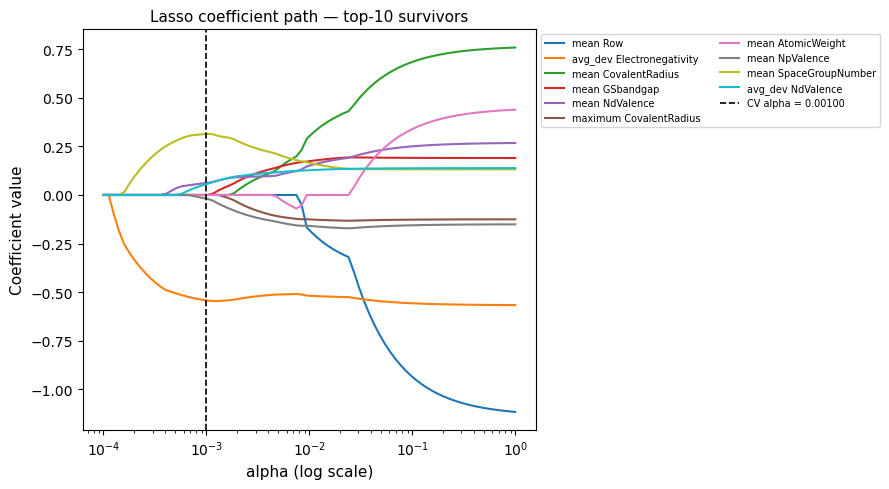

In [12]:
# Cell C3b — Lasso coefficient path plot (top-10 survivors)
# LECTURE DEMO

from sklearn.linear_model import lasso_path

top10_feat = survivors.abs().nlargest(10).index.tolist()
top10_idx  = [list(feature_cols).index(f) for f in top10_feat]

_, coef_path, _ = lasso_path(
    X_train_scaled[:, top10_idx], y_train,
    alphas=np.logspace(-4, 0, 80)
)

fig, ax = plt.subplots(figsize=(9, 5))
for i, feat in enumerate(top10_feat):
    ax.semilogx(np.logspace(-4, 0, 80), coef_path[i], lw=1.5,
                label=feat.replace('MagpieData ', ''))
ax.axvline(lasso_cv.alpha_, color='black', lw=1.2, ls='--',
           label=f'CV alpha = {lasso_cv.alpha_:.5f}')
ax.set_xlabel('alpha (log scale)', fontsize=11)
ax.set_ylabel('Coefficient value', fontsize=11)
ax.set_title('Lasso coefficient path — top-10 survivors', fontsize=11)
ax.legend(fontsize=7, ncol=2, bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig('C3b_lasso_path.png', dpi=150, bbox_inches='tight')
plt.show()

### C4 - Task: model comparison table

In [13]:
# Cell C4 — Task: fill in the model comparison table
# YOUR CODE HERE

# Build a DataFrame with columns: Model | R2 | MAE (eV/atom) | RMSE (eV/atom)
df_perf=pd.DataFrame({'Model':['OLS','Ridge','Lasso'],'R2':[r2_ols,r2_ridge,r2_lasso],'MAE':[mae_ols,mae_ridge,mae_lasso],'RMSE':[rmse_ols,rmse_ridge,rmse_lasso]})

print(df_perf)

# Include rows for: OLS, Ridge (RidgeCV), Lasso (LassoCV)
# Print the table
# Which model performed best on this dataset, and why?
print("\nRidge performed the best but the performance between Ridge and OLS is so close I don't think multicolinearity is causing instability with OLS")



   Model        R2       MAE      RMSE
0    OLS  0.919271  0.230620  0.300500
1  Ridge  0.919272  0.230620  0.300498
2  Lasso  0.915300  0.237568  0.307801

Ridge performed the best but the performance between Ridge and OLS is so close I don't think multicolinearity is causing instability with OLS


**C4 Reflection** *(answer in this cell)*

Which regularization method (Ridge or Lasso) performed better on test $R^2$?
Does the answer surprise you, given that Lasso selected only a subset of features?
What does this tell you about the information content of the discarded features?

*Your answer here:*
Ridge performed better on the R² test. This does somewhat surprise me, but it indicates that the features Lasso discarded still contained useful predictive information. Lasso tends to drop features that are weak or correlated with others, but correlated features can still contribute additional signal. Because Ridge shrinks coefficients rather than eliminating them, it was able to use that extra information and achieve slightly better performance.

---
## Part D - Polynomial Extension
**Connects to: Lecture Segment 5, Sandfeld Ch. 12**

### D1 - Polynomial features on the Lasso-selected subset
**Lecture demo - reproduce and understand**

In [12]:
# Cell D1 — Polynomial degree-2 features on top-5 Lasso survivors
# LECTURE DEMO
# ⚠️ Apply PolynomialFeatures ONLY to the Lasso-selected subset.
#    Applying to all 132 features creates ~8,700 columns and will crash the kernel.

top5_feat = survivors.abs().nlargest(5).index.tolist()
top5_idx  = [list(feature_cols).index(f) for f in top5_feat]

print(f"Top-5 Lasso features selected for polynomial extension:")
for f in top5_feat:
    print(f"  {f}")

poly = PolynomialFeatures(degree=2, include_bias=False)
X_tr_poly = poly.fit_transform(X_train_scaled[:, top5_idx])
X_te_poly = poly.transform(X_test_scaled[:, top5_idx])
print(f"\nPolynomial feature count: {X_tr_poly.shape[1]}  (from 5 → degree-2)")

Top-5 Lasso features selected for polynomial extension:
  MagpieData mean Row
  MagpieData avg_dev Electronegativity
  MagpieData mean CovalentRadius
  MagpieData mean GSbandgap
  MagpieData mean NdValence

Polynomial feature count: 20  (from 5 → degree-2)


### D2 - Task: fit Ridge on polynomial features and compare

In [13]:
# Cell D2 — Task: fit Ridge on polynomial features and add to comparison
# YOUR CODE HERE

# 1. Fit RidgeCV (alphas=np.logspace(-3, 4, 50), cv=5) on X_tr_poly
alphas=np.logspace(-3,4,50)

ridge_cv_2 = RidgeCV(alphas=alphas, cv=5, scoring='r2')
ridge_cv_2.fit(X_tr_poly, y_train)
y_pred_ridge_2 = ridge_cv_2.predict(X_te_poly)

r2_ridge_2 = r2_score(y_test, y_pred_ridge_2)
mae_ridge_2  = mean_absolute_error(y_test, y_pred_ridge_2)
rmse_ridge_2 = np.sqrt(mean_squared_error(y_test, y_pred_ridge_2))

print(f"RidgeCV best alpha: {ridge_cv.alpha_:.4f}")
print(f"Ridge  R²:   {r2_ridge_2:.3f}")
print(f"Ridge  MAE:  {mae_ridge:.3f} eV/atom")
print(f"Ridge RMSE: {rmse_ridge_2:.3f}")

new_row={'Model':'poly','R2':r2_ridge_2,'MAE':mae_ridge_2,'RMSE':rmse_ridge_2}


df_perf_new=pd.concat([df_perf,pd.DataFrame([new_row])],ignore_index=True)

print(f"\n{df_perf_new}")
print('\ndoes not improve over ridge')
# 2. Predict on X_te_poly
# 3. Report: best alpha, R², MAE, RMSE
# 4. Add a row to your C4 comparison table (reprint the full table)
# 5. Does the polynomial extension improve over linear Ridge?




RidgeCV best alpha: 0.0072
Ridge  R²:   0.900
Ridge  MAE:  0.231 eV/atom
Ridge RMSE: 0.335

   Model        R2       MAE      RMSE
0    OLS  0.919271  0.230620  0.300500
1  Ridge  0.919272  0.230620  0.300498
2  Lasso  0.915300  0.237568  0.307801
3   poly  0.899718  0.254271  0.334920

does not improve over ridge


**D2 Reflection** *(answer in this cell)*

Did adding polynomial (degree-2) interaction terms improve $R^2$ over the linear Ridge model?
If yes, name one physical interaction between the two top features that a degree-2 term could capture.
If not, what does that tell you about the linearity of the formation energy landscape in MAGPIE feature space?

*Your answer here:*
Adding degree‑2 polynomial terms did not improve the R2 over the linear Ridge model. This indicates that the formation energy landscape in MAGPIE feature space is largely linear, and nonlinear interactions between features do not add meaningful predictive power. The linear model already captures the dominant structure in the data.

---
## Part E - RF Baseline
**Connects to: Lecture Segment 5, Sandfeld Ch. 13**

### E1 - Train Random Forest on formation energy
**Lecture demo - reproduce and understand**

In [14]:
# Cell E1 — RandomForestRegressor on Ef_eV_atom
# LECTURE DEMO

rf = RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)          # Note: no scaling needed for RF
y_pred_rf = rf.predict(X_test)

r2_rf   = r2_score(y_test, y_pred_rf)
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("Random Forest on Ef_eV_atom:")
print(f"  R²:   {r2_rf:.3f}")
print(f"  MAE:  {mae_rf:.3f} eV/atom")
print(f"  RMSE: {rmse_rf:.3f} eV/atom")

Random Forest on Ef_eV_atom:
  R²:   0.994
  MAE:  0.051 eV/atom
  RMSE: 0.084 eV/atom


### E2 - Final comparison table and residual plot
**Lecture demo**

Final model comparison:
     Model    R²  MAE (eV/at)  RMSE (eV/at)
       OLS 0.919        0.231         0.300
Ridge (CV) 0.919        0.231         0.300
Lasso (CV) 0.915        0.238         0.308
        RF 0.994        0.051         0.084


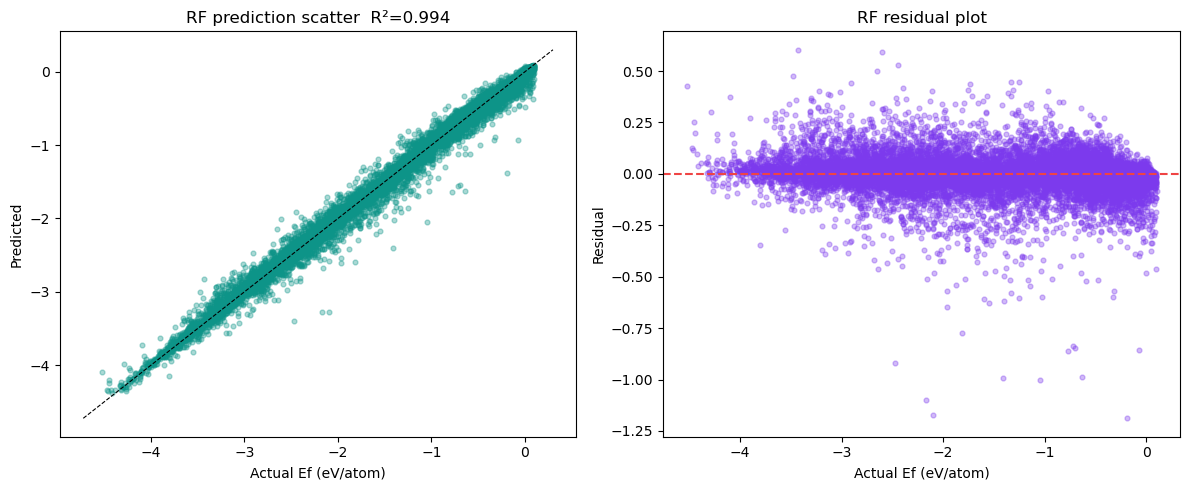

In [15]:
# Cell E2 — Final comparison table and residual plot for RF
# LECTURE DEMO

results = pd.DataFrame({
    'Model':       ['OLS', 'Ridge (CV)', 'Lasso (CV)', 'RF'],
    'R²':          [round(r2_ols,3), round(r2_ridge,3), round(r2_lasso,3), round(r2_rf,3)],
    'MAE (eV/at)': [round(mae_ols,3), round(mae_ridge,3), round(mae_lasso,3), round(mae_rf,3)],
    'RMSE (eV/at)':[round(rmse_ols,3), round(rmse_ridge,3), round(rmse_lasso,3), round(rmse_rf,3)],
})
print("Final model comparison:")
print(results.to_string(index=False))

# Residual plot for RF
residuals_rf = y_pred_rf - y_test
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_test, y_pred_rf, alpha=0.35, s=12, color='#0D9488')
lim = [y_test.min()-0.2, y_test.max()+0.2]
axes[0].plot(lim, lim, 'k--', lw=0.8)
axes[0].set_xlabel('Actual Ef (eV/atom)'); axes[0].set_ylabel('Predicted')
axes[0].set_title(f'RF prediction scatter  R²={r2_rf:.3f}')

axes[1].scatter(y_test, residuals_rf, alpha=0.35, s=12, color='#7C3AED')
axes[1].axhline(0, color='#EF4444', lw=1.5, ls='--')
axes[1].set_xlabel('Actual Ef (eV/atom)'); axes[1].set_ylabel('Residual')
axes[1].set_title('RF residual plot')

plt.tight_layout()
plt.savefig('E2_rf_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### E3 - Task: complete the comparison and interpret

        Model        R²  MAE (eV/at)  RMSE (eV/at)
0         OLS  0.919000     0.231000       0.30000
1  Ridge (CV)  0.919000     0.231000       0.30000
2  Lasso (CV)  0.915000     0.238000       0.30800
3          RF  0.994000     0.051000       0.08400
4        poly  0.899718     0.254271       0.33492
No, it RF does not outperform Ridge by the same margin as for bandgap. The property of formation energy that makes linear models more competitive is that the features affecting it are small independent variables that are additive.


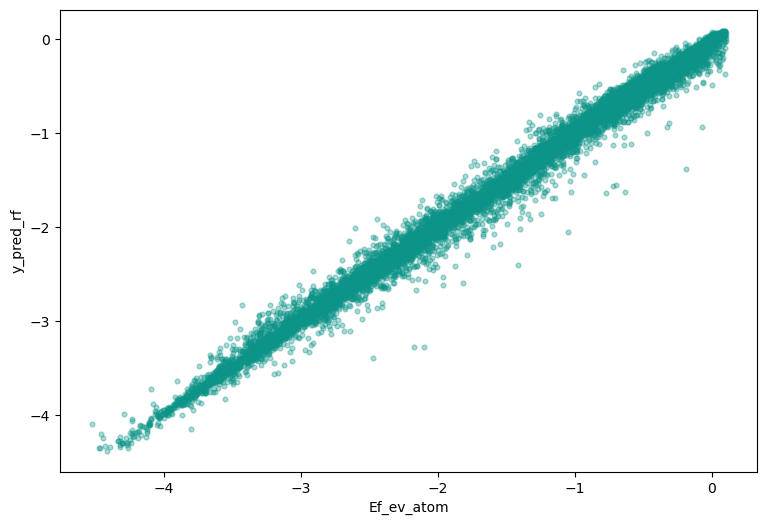

In [16]:
# Cell E3 — Task: complete the comparison table and interpret
# YOUR CODE HERE

# 1. Add the Poly-Ridge row from Part D to the results table above (reprint it)

new_df=pd.DataFrame({'Model':['poly'],'R²':[r2_ridge_2],'MAE (eV/at)':[mae_ridge_2],'RMSE (eV/at)':[rmse_ridge_2]})

new_results=pd.concat([results,new_df],ignore_index=True)

print(new_results)

# 2. Make a scatter plot of RF predictions vs. actual Ef_eV_atom
#    Save as 'E3_rf_scatter.png'

fig,ax=plt.subplots(figsize=(9,6))

ax.scatter(y_test,y_pred_rf,alpha=0.35, s=12, color='#0D9488')
ax.set_xlabel('Ef_ev_atom')
ax.set_ylabel('y_pred_rf')
plt.savefig('y_pred vs. Ef.png', dpi=150, bbox_inches='tight')

# 3. Answer: does the RF outperform Ridge by as much as the Week 5 RF
#    outperformed Ridge on band_gap?
#    If not, what property of formation energy makes linear models more competitive?

print("No, it RF does not outperform Ridge by the same margin as for bandgap. The property of formation energy that makes linear models more competitive is that the features affecting it are small independent variables that are additive.")



**E3 Reflection** *(answer in this cell)*

Formation energy and band gap are both predicted from the same MAGPIE features,
yet the relative performance of Ridge vs. RF differs between the two properties.
What physical property of formation energy makes it more linearly predictable?
Connect your answer to a concept from Week 3 (statistical distributions) and Week 6 (regularization).

*Your answer here:*
The physical property of formation energy that makes it more linearly predictable is that it is the sum of many small independent contributions such as bond energy. For this reason the formation energy is approximatley normally distributed. Normal distributions are modeled well by linear regression. Also, because the relationhip is mostly lineat Ridge only needs to shrink coefficients and doesn't need to include nonlinear reactions as evidenced by the polynomial Ridge. 

---
## Part F - Reflection
**Complete after finishing Parts A–E**

### F1 - Lasso selection and bonding contributions

In 3–4 sentences: what does the Lasso feature selection tell you about which
composition descriptors drive thermodynamic stability in the MP dataset?
Name the top surviving features and connect each to a physical bonding mechanism
(ionic character, size mismatch, electronegativity difference, valence electron count, etc.).

*Your answer here:*
The Lasso feature selection tells me that the composition descriptors that drive themodynamic stability in the MP dataset are those mostly concerned with bonding strength. The top surviving features that stabilize the energy were for example: mean row, avg_dev electronegativty, max covalent radius, mean p valence electrons. Mean row captures periodic trends in orbital size and bond strength. The electronegativy indicates ionic bond character which increases stability with greater ionic bond character. The max convalent radius indicates bond length which is a proxy for bond strength. Valence electron count affects electronegativty and bonding strength. 

### F2 - Final project connection

For your final project: would Ridge or Lasso be sufficient to predict your target property,
or do you expect a nonlinear model (RF, GBM, GNN) to be necessary?
Justify your answer based on the physical origin of your property — is it additive (linear-friendly)
or does it depend on structural transitions or coordination-environment changes (nonlinear)?

*Your answer here:*
I suspect that Ridge or Lasso will not be sufficient to predict the energy capacity of lithium ion batteries in operation. I expect that RF or a similar model that accounts for nonlinear behavior will be necessary. The reason for this is that battery ageing mechanims generally follow an nonlinear relationship, usually modeled by an arrenhius type relationship for both calendar ageing and cycling ageing mechanisms. Effects of SOC, time, and temperature in partcular are not additive to the SOH (state of health) decrease. This makes sense because the degradation mechanisms are the result of diffusion processes and reactions at the electrodes. 

---
## Day 2

> **This section is covered during the Day 2 lab session.**

### Demo 1 - Lasso feature selection: which MAGPIE features survive?
**Lecture demo**

Lasso survivors: 81 / 132 features

Top 5 stabilising features (most negative coefficient = drives Ef negative):
MagpieData mean Row                    -0.6551
MagpieData avg_dev Electronegativity   -0.5397
MagpieData maximum CovalentRadius      -0.1954
MagpieData mean NpValence              -0.1742
MagpieData maximum NpUnfilled          -0.1227

Top 5 destabilising features (most positive coefficient):
MagpieData mean SpaceGroupNumber    0.1453
MagpieData mean AtomicWeight        0.1836
MagpieData mean NdValence           0.2000
MagpieData mean GSbandgap           0.2014
MagpieData mean CovalentRadius      0.5341


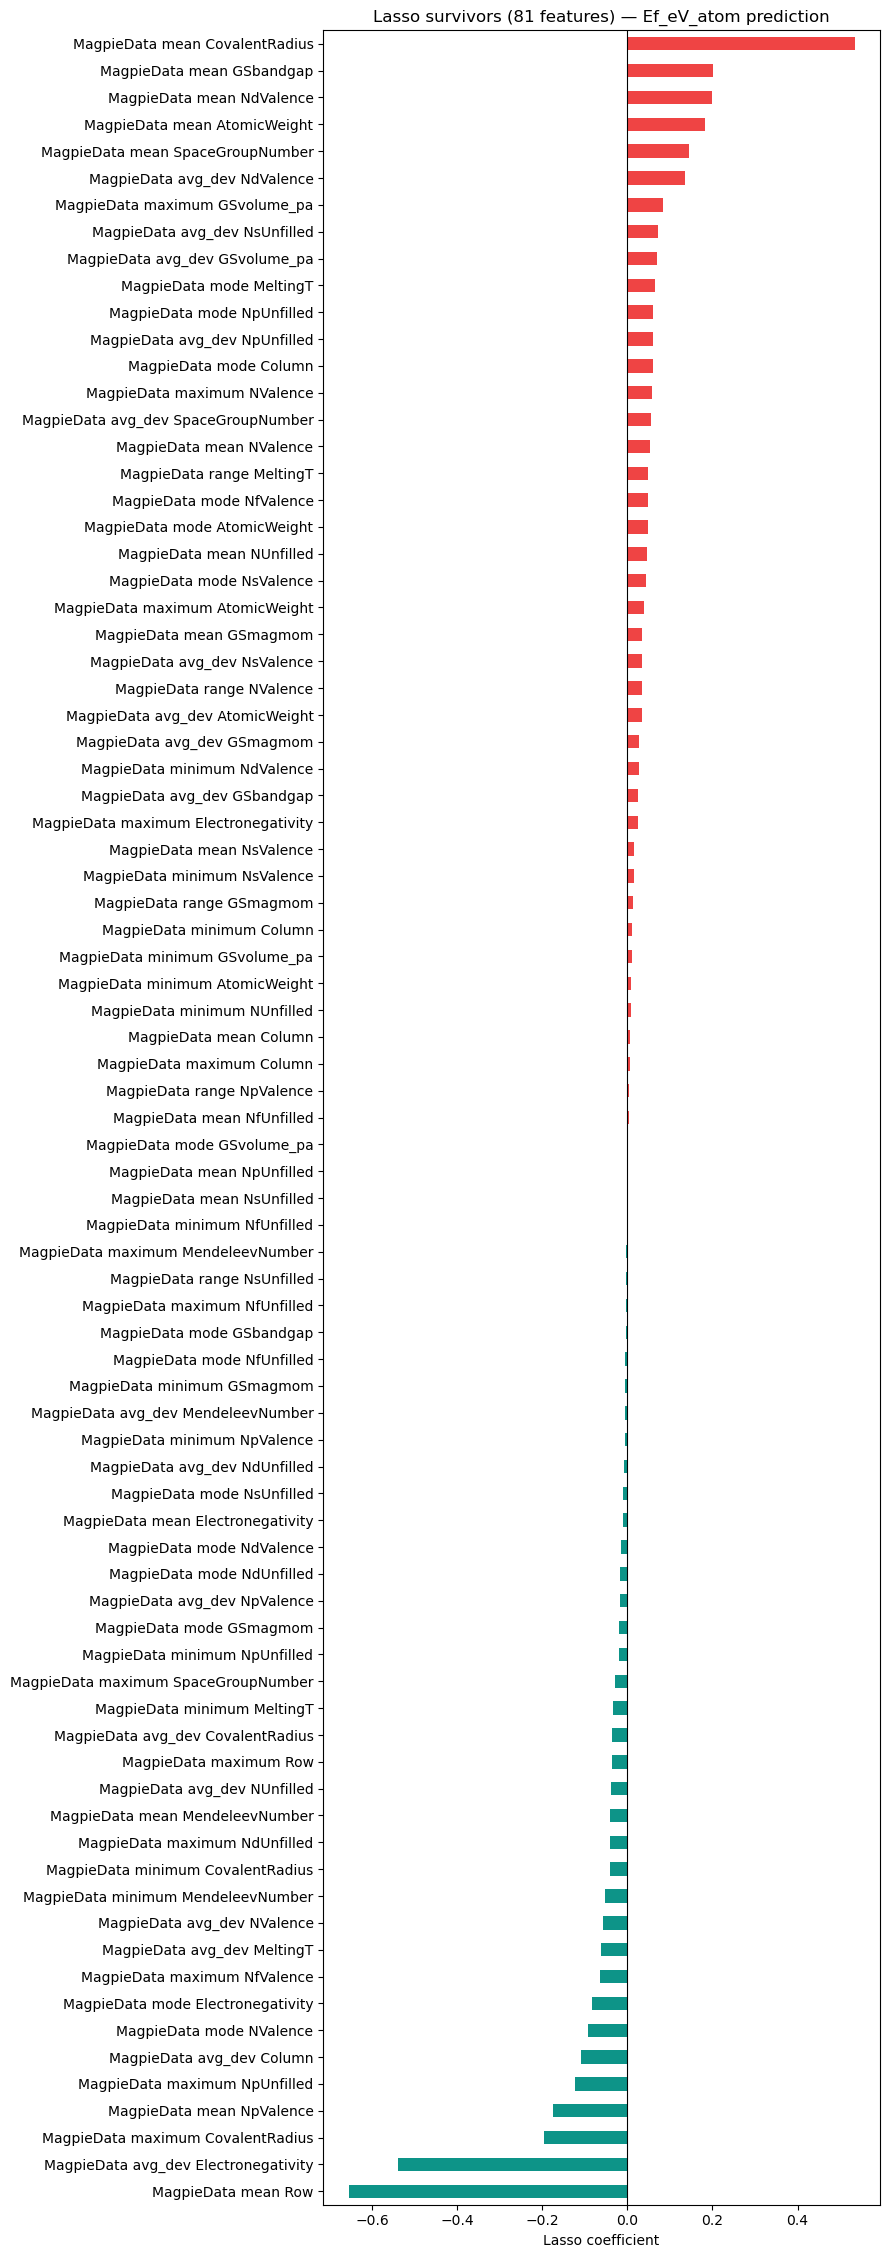

In [17]:
# Demo 1 — Lasso survivors: visualise and physically interpret
# LECTURE DEMO

import pandas as pd
import matplotlib.pyplot as plt

survivors = pd.Series(lasso_cv.coef_, index=feature_cols)
survivors = survivors[survivors != 0].sort_values()

print(f"Lasso survivors: {len(survivors)} / {len(feature_cols)} features")
print()
print("Top 5 stabilising features (most negative coefficient = drives Ef negative):")
print(survivors.head(5).round(4).to_string())
print()
print("Top 5 destabilising features (most positive coefficient):")
print(survivors.tail(5).round(4).to_string())

fig, ax = plt.subplots(figsize=(9, max(4, len(survivors)*0.28)))
colors = ['#EF4444' if v > 0 else '#0D9488' for v in survivors.values]
survivors.plot(kind='barh', color=colors, ax=ax)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Lasso coefficient')
ax.set_title(f'Lasso survivors ({len(survivors)} features) — Ef_eV_atom prediction')
plt.tight_layout()
plt.savefig('Day2_lasso_survivors.png', dpi=150, bbox_inches='tight')
plt.show()

### Demo 2 - Compare all models: where does regularisation help most?
**Lecture demo**

In [18]:
# Demo 2 — Full model comparison with confidence context
# LECTURE DEMO

import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import Ridge

results_day2 = {}
for name, (model, X_tr, X_te) in {
    'OLS':       (ols,      X_train_scaled, X_test_scaled),
    'Ridge':     (ridge_cv, X_train_scaled, X_test_scaled),
    'Lasso':     (lasso_cv, X_train_scaled, X_test_scaled),
    'RF':        (rf,       X_train,        X_test),
}.items():
    y_pred = model.predict(X_te)
    results_day2[name] = {
        'R²':   round(r2_score(y_test, y_pred), 3),
        'MAE':  round(mean_absolute_error(y_test, y_pred), 3),
        'RMSE': round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
    }

df_results = pd.DataFrame(results_day2).T
print("Full model comparison — Ef_eV_atom prediction:")
print(df_results.to_string())
print()
print("Key insight: Ridge and Lasso achieve similar R² to RF.")
print("For Ef (near-Gaussian, additive), linear models are competitive.")
print("Compare to Week 5: RF outperformed Ridge much more on band_gap (non-Gaussian).")

Full model comparison — Ef_eV_atom prediction:
          R²    MAE   RMSE
OLS    0.919  0.231  0.300
Ridge  0.919  0.231  0.300
Lasso  0.915  0.238  0.308
RF     0.994  0.051  0.084

Key insight: Ridge and Lasso achieve similar R² to RF.
For Ef (near-Gaussian, additive), linear models are competitive.
Compare to Week 5: RF outperformed Ridge much more on band_gap (non-Gaussian).


### Demo 3 - Coefficient stability: how sensitive is Ridge to alpha?
**Lecture demo**

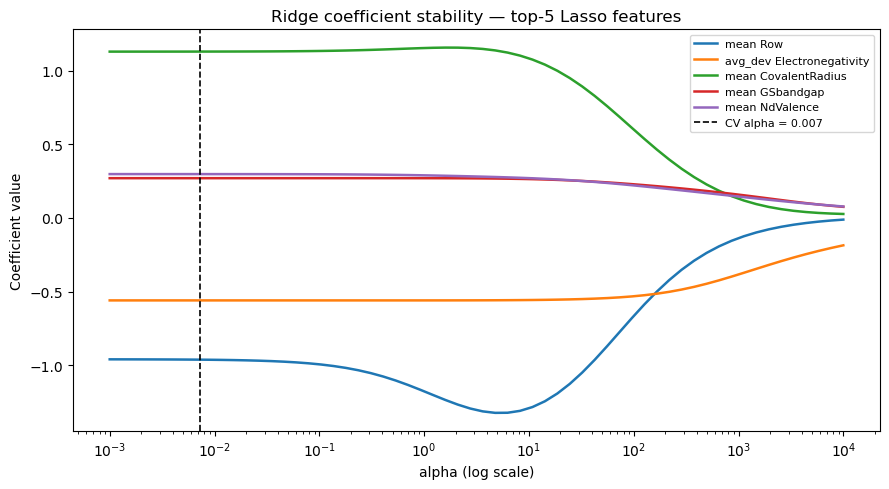

In [19]:
# Demo 3 — Ridge coefficient stability across alpha values
# LECTURE DEMO

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge

alphas = np.logspace(-3, 4, 60)
top5_feat = pd.Series(lasso_cv.coef_, index=feature_cols).abs().nlargest(5).index.tolist()
top5_idx  = [list(feature_cols).index(f) for f in top5_feat]

coefs = []
for alpha in alphas:
    ridge_a = Ridge(alpha=alpha)
    ridge_a.fit(X_train_scaled, y_train)
    coefs.append(ridge_a.coef_[top5_idx])

coefs = np.array(coefs)

fig, ax = plt.subplots(figsize=(9, 5))
for i, feat in enumerate(top5_feat):
    label = feat.replace('MagpieData ', '')[:35]
    ax.semilogx(alphas, coefs[:, i], lw=1.8, label=label)
ax.axvline(ridge_cv.alpha_, color='black', lw=1.2, ls='--',
           label=f'CV alpha = {ridge_cv.alpha_:.3f}')
ax.set_xlabel('alpha (log scale)'); ax.set_ylabel('Coefficient value')
ax.set_title('Ridge coefficient stability — top-5 Lasso features')
ax.legend(fontsize=8, bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig('Day2_ridge_stability.png', dpi=150, bbox_inches='tight')
plt.show()

**Day 2 Discussion questions:**

1. From Demo 1: do the Lasso-surviving features make physical sense for formation energy? Name one surviving feature and explain the bonding mechanism it encodes.

2. From Demo 2: why does the RF–Ridge gap for Ef (this week) differ from the RF–Ridge gap for band_gap (Week 5)? What property of formation energy makes linear models more competitive?

3. From Demo 3: which features are most stable (coefficient barely changes across alpha) and which are most sensitive? What does instability in a Ridge coefficient tell you about that feature?

---
## Submission Checklist

**Part A — Load & Inspect**
- [ ] A1: Dataset loaded; target statistics printed
- [ ] A2: Distribution plot saved (`A2_ef_distribution.png`); reflection answered
- [ ] A3: Feature matrix set up; X shape and y range printed

**Part B — Split & Scale**
- [ ] B1: Stratified split complete; sizes and distribution statistics printed
- [ ] B2: Scaler fit on train only; mean/std confirmed

**Part C — OLS, Ridge & Lasso**
- [ ] C1: OLS trained; top coefficients printed; reflection answered
- [ ] C2: RidgeCV trained; best alpha reported; validation curve saved (`C2_ridge_validation_curve.png`)
- [ ] C3: LassoCV trained; n_nonzero features reported; coefficient path saved (`C3b_lasso_path.png`)
- [ ] C4: Task cell contains working code; comparison table printed; reflection answered

**Part D — Polynomial Extension**
- [ ] D1: Top-5 Lasso features identified; polynomial features created
- [ ] D2: Task cell contains working code; Poly-Ridge result reported; reflection answered

**Part E — RF Baseline**
- [ ] E1: RF trained on Ef_eV_atom; $R^2$, MAE, RMSE printed
- [ ] E2: Final comparison table printed; residual plot saved (`E2_rf_comparison.png`)
- [ ] E3: Task cell contains working code; RF scatter saved (`E3_rf_scatter.png`); reflection answered

**Part F — Reflection**
- [ ] F1: Written answer (3–4 sentences, named features with physical mechanisms)
- [ ] F2: Written answer specific to your final project

- [ ] All reflection cells answered (no placeholder text)
- [ ] AI disclosure note updated or deleted at the top of the notebook
- [ ] File renamed: `[LastName]_week6.ipynb`
**Final check:** Run `Kernel → Restart & Run All`. All cells must execute without errors before submitting.